# BronFormat

## Packages

In [1]:
from pathlib import Path

import brofopy as bfp

bfp.show_versions()

Python      : 3.13.5
Brofopy     : 0.0.0
Scipy       : 1.17.1
Pandas      : 3.0.3
Hydropandas : 0.18.1
H5py        : 3.16.0



## Loading a file

In [2]:
test_data_path = Path.cwd().parent / "tests/data/"
bf = bfp.read_bronformat(test_data_path / "gld_bhr.hdf5")
bf

BronFormat(BHR, Cache, File, GIS, GLD, GMN, GMW, IN, Proces, QC)

## Exploring the `BronFormat` object

In [3]:
bf.BHR["[0, 0]"]

{'Borehole': {'BHRID': 12.0,
  'BoringOperator': '01088169',
  'BoringProcedure': 'SIKB2001vanafV6.0',
  'Completed': 0,
  'Contaminated': 0,
  'ContinuouslySampled': 'nee',
  'DeliveryContext': 'publiekeTaak',
  'DescribedMaterial': 'grond',
  'DescriptionLocation': 'veld',
  'DescriptionOperator': '01088169',
  'DescriptionProcedure': 'ISO14688d1v2019c2020',
  'DescriptionQuality': 'klasse3',
  'Discipline': 'geotechniek',
  'EndDate': 739742.0,
  'Excavated': 0,
  'HorPosMethod': 'RTKGPS5tot10cm',
  'IsCasing': 1,
  'IsRockRchd': 0,
  'Preparation': 'geen',
  'ResearchOperator': '01088169',
  'SampleMoistness': 'veldvochtig',
  'SamplingProcedure': 'ISO22475d1v2006',
  'SoilUse': 'geenBodemgebruik',
  'StartDate': 739742.0,
  'StopCriterion': 'einddoel',
  'SurfaceLevel': 0.374,
  'SurveyProcedure': 'EN1997d2v2007',
  'SurveyPurpose': 'verkennendOnderzoek',
  'VertPosMethod': 'RTKGPS4tot10cm',
  'XCoordinate': 190889.296,
  'YCoordinate': 535882.968},
 'History': {'BHRID': 12.0,
  '

In [4]:
bf.GLD

{'GLD000000150371': {'Adm': {'AccParty': '51048329',
   'BROID': 'GLD000000150371',
   'DvRespParty': '74503812',
   'GLDID': 1.0,
   'LastRgstrEvent': 1.0,
   'ObjRgstrDateTime': 740117.4259143518,
   'QualityRegime': 0},
  'Dossier': {'GMWBROID': 'GMW000000099678', 'GMWID': 1.0, 'TubeNo': 1},
  'History': {'DateTime': nan,
   'EventData': [0, 0],
   'EventName': 'Start registratie',
   'GLDID': 1.0,
   'SourceID': 0},
  'Source': {'BaroID': 0,
   'Battery': nan,
   'Changes': [0, 0],
   'Drift': 0.0,
   'File': 'Controlemetingen',
   'GLDID': 1.0,
   'Gravity': nan,
   'Investigator': 'onbekend',
   'IsInterim': 0,
   'LoggerBrand': 'Keller',
   'LoggerDepth': 2.81,
   'LoggerSerial': '1676500',
   'Measurements': [{'DateTime': 739857.6569444444, 'RawValue': -1.595},
    {'DateTime': 739893.4402777777, 'RawValue': -1.555},
    {'DateTime': 740026.5820334954, 'RawValue': -1.04},
    {'DateTime': 739857.625, 'RawValue': 1.257654070854187},
    {'DateTime': 739857.6666666666, 'RawValue'

## Extensions

### Coupling to Panads

In [5]:
df = bf.to_dataframe()
df.head()

DateTime  RawValue
Entity BROID                                                  
GLD    GLD000000150371 2025-08-28 15:45:59.999996427 -1.595000
       GLD000000150371 2025-10-03 10:33:59.999995751 -1.555000
       GLD000000150371 2026-02-13 13:58:07.694004175 -1.040000
       GLD000000150371 2025-08-28 15:00:00.000000000  1.257654
       GLD000000150371 2025-08-28 15:59:59.999996650  1.240897

### Coupling to HydroPandas

In [10]:
oc = bf.to_obscollection(entity="GLD", name="BronFormat Export")
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs
name,,,,,,,,,,,,,
GLD000000150371,190918.35,535755.82,GLD000000150371,,BronFormat,,1,-1.782,-2.782,-0.263,0.248,False,GroundwaterObs GLD000000150371 -----metadata--...


In [11]:
obs = oc.loc["GLD000000150371", "obs"]
obs

,GLD000000150371
x,190918.35
y,535755.82
location,GLD000000150371
filename,
source,BronFormat
unit,
tube_nr,1
screen_top,-1.782
screen_bottom,-2.782
ground_level,-0.263


<Axes: xlabel='DateTime'>

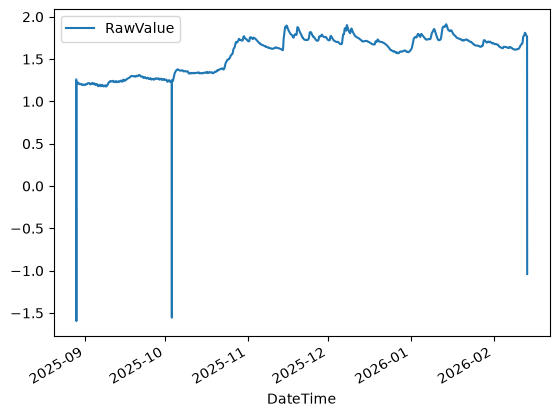

In [12]:
obs.sort_index().plot()